In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from torchvision.transforms import GaussianBlur
import torch
import tifffile as tiff
from scipy import ndimage, fft  # fft = scipy.fft (NumPy-compatible)
from skimage.restoration import richardson_lucy
from skimage.feature import peak_local_max

### Load sims, form images, stack them, save the stack in imagej friendly format

In [399]:
'''Load events'''
#df = pd.read_feather("/home/jeff/data/Migdal/simulation/C+F_with_displacements_good.feather") #simNRs
df = pd.read_pickle("/home/jeff/data/Migdal/simulation/NR_file_matches_sample1_good_with_images.pkl") #real data

In [3]:
### Only for sims
def get_intensity_ratio(df,i,bin_fact=4):
    tmp = df.iloc[i]
    im = np.histogram2d(tmp['col'],tmp['row'],weights=tmp['intensity'],bins=(2048//bin_fact,1152//bin_fact),range=((0,2048),(0,1152)))[0].T
    gaussian_blur = GaussianBlur(kernel_size = 9, sigma = (4/3,4/3))
    out = gaussian_blur(torch.tensor(im).unsqueeze(0)).squeeze(0).numpy()
    ratio = out[tmp['cam_vtx_y']//bin_fact,tmp['cam_vtx_x']//bin_fact]/out.max()
    return ratio

In [4]:
df['vertex_to_peak_intensity_ratio'] = [get_intensity_ratio(df,i) for i in tqdm(range(0,len(df)))]

100%|████████████████████████████████████████████████████████████| 5829/5829 [03:29<00:00, 27.88it/s]


In [5]:
#df.to_feather("/home/jeff/data/Migdal/simulation/C+F_with_displacements_good.feather")

In [400]:
def form_image(df,i,bin_fact,threshold = None,gb = False,sim=True):
    tmp = df.iloc[i]
    if sim:
        im = np.histogram2d(tmp['col'],tmp['row'],weights=tmp['intensity'],bins=(2048//bin_fact,1152//bin_fact),range=((0,2048),(0,1152)))[0].T
        if gb:
            gaussian_blur = GaussianBlur(kernel_size = 9, sigma = (4/3,4/3))
            out = gaussian_blur(torch.tensor(im).unsqueeze(0)).squeeze(0).numpy()
        else:
            out = im
    else:
        out = tmp['im'].copy()
        
    if threshold is not None:
        out[out<threshold] = 0
    return out

In [7]:
binning=4
gb=True
im = form_image(df,0,bin_fact = binning,gb=gb)

In [8]:
lowE = df.query('truth_energy < 250')
highE = df.query('truth_energy >= 250')
lowE.index = [i for i in range(0,len(lowE))]
highE.index = [i for i in range(0,len(highE))]

In [448]:
from tqdm import tqdm
ims = []
for i in tqdm(range(0,len(df))):
    ims.append(form_image(df,i,bin_fact = binning,gb=gb,threshold=10,sim=False))
stack = np.stack(ims,axis=0)

100%|████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 1851.82it/s]


In [449]:
stack.dtype

dtype('float64')

In [450]:
def to_uint8_sparse(stk, pct=(0, 100), ignore_zeros=True, clip_negative=True):
    a = stk.astype(np.float32, copy=False)

    if clip_negative:
        a = np.maximum(a, 0)

    # Choose pixels to estimate contrast from
    sample = a[a != 0] if ignore_zeros else a.ravel()

    if sample.size == 0:                   # stack is all zeros
        return np.zeros_like(a, dtype=np.uint8)

    lo, hi = np.percentile(sample, pct)

    out = np.clip(a, lo, hi)
    out = ((out - lo) / (hi - lo) * 255).astype(np.uint8)
    return out
    
u8_stack = to_uint8_sparse(stack)                   # shape (Z, H, W), dtype uint8

In [451]:
u8_stack.max()

255

In [452]:
tiff.imwrite(
    '/home/jeff/Fiji/data/NR_realData_stack_lowthresh.tif',
    u8_stack,
    photometric='minisblack',      # 0 = black, 255 = white
    metadata={'axes': 'ZYX'},      # tells ImageJ it’s a z-stack
    compression='zlib',            # or 'none' / 'jpeg' / 'lzw'
    bigtiff=True if u8_stack.nbytes > 4_000_000_000 else False
)

In [9]:
ridgepath='/home/jeff/Fiji/data'
lowEridge = pd.read_csv(os.path.join(ridgepath,"NR_sim_stack_lowE.csv"))
highEridge = pd.read_csv(os.path.join(ridgepath,"NR_sim_stack_highE.csv"))

In [10]:
lowEridge = lowEridge.query('Class == "no_junc"')
highEridge = highEridge.query('Class == "no_junc"')
lowEridge.index = [i for i in range(0,len(lowEridge))]
highEridge.index = [i for i in range(0,len(highEridge))]

In [11]:
lowEridgegrp = lowEridge.groupby('Frame').agg(list).reset_index()

In [12]:
highEridgegrp = highEridge.groupby('Frame').agg(list).reset_index()

In [13]:
lowE['Frame'] = lowE.index + 1
highE['Frame'] = highE.index + 1

/tmp/ipykernel_119404/250266658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lowE['Frame'] = lowE.index + 1
/tmp/ipykernel_119404/250266658.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highE['Frame'] = highE.index + 1


In [14]:
lowEmatch = lowE.loc[lowE['Frame'].isin(lowEridge['Frame'])]
highEmatch = highE.loc[highE['Frame'].isin(highEridge['Frame'])]

In [15]:
lowEmatch.index = [i for i in range(0,len(lowEmatch))]
highEmatch.index = [i for i in range(0,len(highEmatch))]

In [16]:
lowEmatch['x_ridge'] = lowEridgegrp['X']
lowEmatch['y_ridge'] = lowEridgegrp['Y']

/tmp/ipykernel_119404/3904396131.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lowEmatch['x_ridge'] = lowEridgegrp['X']
/tmp/ipykernel_119404/3904396131.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lowEmatch['y_ridge'] = lowEridgegrp['Y']


In [17]:
highEmatch['x_ridge'] = highEridgegrp['X']
highEmatch['y_ridge'] = highEridgegrp['Y']

/tmp/ipykernel_119404/1661523030.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highEmatch['x_ridge'] = highEridgegrp['X']
/tmp/ipykernel_119404/1661523030.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highEmatch['y_ridge'] = highEridgegrp['Y']


In [18]:
def plot_ridge(df,i,bin_fact=4,gb=True,threshold=5000):
    tmp = df.iloc[i]
    im = np.histogram2d(tmp['col'],tmp['row'],weights=tmp['intensity'],bins=(2048//bin_fact,1152//bin_fact),range=((0,2048),(0,1152)))[0].T
    if gb:
        gaussian_blur = GaussianBlur(kernel_size = 9, sigma = (4/3,4/3))
        out = gaussian_blur(torch.tensor(im).unsqueeze(0)).squeeze(0).numpy()
    else:
        out = im
        
    plt.imshow(out,cmap='jet',aspect='auto')
    if threshold is not None:
        out[out<threshold] = 0
        
    plt.plot(tmp['x_ridge'][-1],tmp['y_ridge'][-1],'o',color='magenta',markersize=8,markeredgecolor='k',lw=2)
    plt.plot(tmp['x_ridge'],tmp['y_ridge'],color='magenta',lw=2)
    
    plt.xlim(tmp['col'].min()//bin_fact-10,tmp['col'].max()//bin_fact+10)
    plt.ylim(tmp['row'].min()//bin_fact-10,tmp['row'].max()//bin_fact+10)
    
    highq = np.unravel_index(np.argmax(out), out.shape)
    plt.scatter(highq[1], highq[0],
                color='cyan', s=120, edgecolor='k',
                label='peak')
    plt.scatter(tmp['cam_vtx_x']//bin_fact,tmp['cam_vtx_y']//bin_fact,color='white',s=120,edgecolor='k')
        
    plt.show()

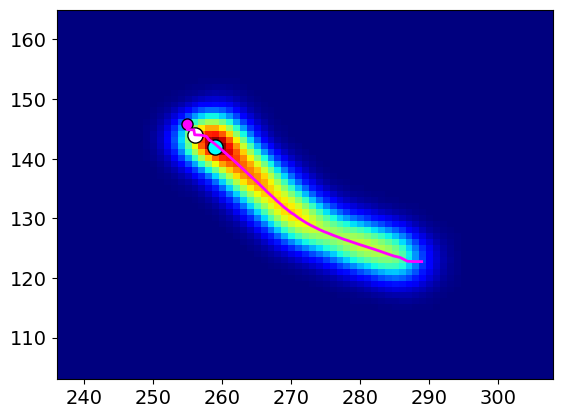

In [202]:
plot_ridge(highEmatch.query('truth_energy > 300'),13,gb=True)

In [22]:
#df = pd.concat([lowEmatch,highEmatch])
#df.index=[i for i in range(0,len(df))]

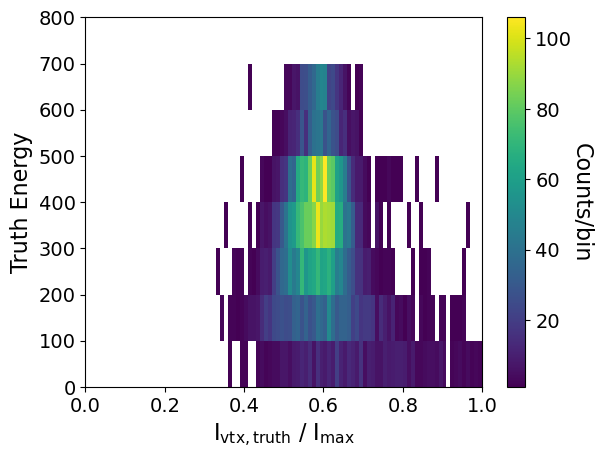

In [295]:
cmap = plt.cm.viridis
cmap.set_under((1,1,1))
plt.hist2d(df['vertex_to_peak_intensity_ratio'],df['truth_energy'],bins=(100,[0,100,200,300,400,500,600,700,800]),cmap=cmap,range=((0,1),(0,900)),vmin=1)
plt.xlabel(r'$\rm I_{vtx,truth}$ / $\rm I_{max}$')
plt.ylabel('Truth Energy')
plt.colorbar().set_label('Counts/bin',rotation=270,labelpad=15)

In [52]:
### Function samples a random ratio given an input energy

xedges = np.linspace(0.0, 1.0, 101)
ybins   = [0,200,300,400,500,600,700,800]
hist, xe, ye = np.histogram2d(
    df['vertex_to_peak_intensity_ratio'], df['truth_energy'],
    bins=(xedges, ybins),
    range=None   # edges already set
)

def sample_ratio_given_energy(y0, hist, xedges, yedges):
    """
    Returns one random x (ratio) drawn from p(x|y=y0) approximated
    by the 2D histogram `hist` with bin-edges `xedges`,`yedges`.
    """
    #find the index j so that yedges[j] <= y0 < yedges[j+1]
    j = np.digitize(y0, yedges) - 1
    j = np.clip(j, 0, hist.shape[1]-1)

    # get the counts along x for that y-bin
    counts = hist[:, j].astype(float)
    total  = counts.sum()
    if total == 0:
        raise ValueError(f"No events in y-bin for y0={y0}")

    # normalize to probabilities
    probs = counts / total

    # sample an x-bin index
    i = np.random.choice(np.arange(len(probs)), p=probs)

    # return a uniformly random x within that bin
    return np.random.uniform(xedges[i], xedges[i+1])

test_E = 350
test_ratio = sample_ratio_given_energy(test_E, hist, xedges, ye)
print("sampled ratio at truth_energy =", test_E, "is", test_ratio)


sampled ratio at truth_energy = 350 is 0.5504866657681226


In [237]:
from scipy.interpolate import UnivariateSpline

def compute_predicted_vertex(df,i,bin_fact=4,plot=True):
    tmp = df.iloc[i]
    arr = np.array([tmp['x_ridge'],tmp['y_ridge']]).T
    idx = arr[:,0].argsort()
    arr = arr[idx]
    spl = UnivariateSpline(arr[:,0],arr[:,1],k=5)
    im = np.histogram2d(tmp['col'],tmp['row'],weights=tmp['intensity'],bins=(2048//bin_fact,1152//bin_fact),range=((0,2048),(0,1152)))[0].T
    if gb:
        gaussian_blur = GaussianBlur(kernel_size = 9, sigma = (4/3,4/3))
        out = gaussian_blur(torch.tensor(im).unsqueeze(0)).squeeze(0).numpy()
    else:
        out = im

    ratio = sample_ratio_given_energy(tmp['truth_energy'], hist, xedges, ye)
    target_intensity = ratio*out.max()

    xtest = np.linspace(min(tmp['x_ridge']),max(tmp['x_ridge']),1001)
    ytest = spl(xtest)
    try:
        for i in range(0,len(xtest)):
            intensity = out[int(np.round(ytest[i])),int(np.round(xtest[i]))]
            if intensity >= target_intensity:
                break
        pred_vtx_x = xtest[i]
        pred_vtx_y = ytest[i]
    except:
        print("Something went wrong, try another event")
        pred_vtx_x = -1
        pred_vtx_y = -1

    if plot:
        plt.imshow(out,cmap='jet',aspect='auto')
        #plt.plot(tmp['x_ridge'][-1],tmp['y_ridge'][-1],'o',color='magenta',markersize=8,markeredgecolor='k',lw=2)
        #plt.plot(tmp['x_ridge'],tmp['y_ridge'],color='magenta',lw=4,label='ridge')
        plt.plot(xtest,ytest,color='w',lw=2,label='spline')
        plt.scatter(tmp['cam_vtx_x']//bin_fact,tmp['cam_vtx_y']//bin_fact,color='white',s=120,edgecolor='k',label='truth vertex')
        plt.scatter(pred_vtx_x,pred_vtx_y,color='k',s=120,edgecolor='k',label = 'predicted vertex')
        highq = np.unravel_index(np.argmax(out), out.shape)
        plt.scatter(highq[1], highq[0],color='cyan', s=120, edgecolor='k',label=r'$\rm I_{max}$')
        plt.xlim(tmp['col'].min()//bin_fact-5,tmp['col'].max()//bin_fact+5)
        plt.ylim(tmp['row'].min()//bin_fact-5,tmp['row'].max()//bin_fact+5)
        plt.legend(ncol=3)
    else:
        highq = np.unravel_index(np.argmax(out), out.shape)
    
    
    return pred_vtx_x, pred_vtx_y, np.sqrt((tmp['cam_vtx_x']//bin_fact-pred_vtx_x)**2+(tmp['cam_vtx_y']//bin_fact-pred_vtx_y)**2)*80/(2048/bin_fact), np.sqrt((tmp['cam_vtx_x']//bin_fact-highq[1])**2+(tmp['cam_vtx_y']//bin_fact-highq[0])**2)*80/(2048/bin_fact)

In [299]:
from scipy.interpolate import UnivariateSpline
import numpy as np
import matplotlib.pyplot as plt

def compute_predicted_vertex(df, i, bin_fact=4, plot=True):
    tmp = df.iloc[i]

    # --- 1) Build and sort your ridge for the spline ---
    arr = np.vstack((tmp['x_ridge'], tmp['y_ridge'])).T
    sort_idx = arr[:,0].argsort()
    arr = arr[sort_idx]  # now arr[0] is the 'start' of the ridge

    # fit a smooth y(x)
    spl = UnivariateSpline(arr[:,0], arr[:,1], k=5)

    # --- 2) Build your (possibly blurred) 2D map ---
    im = np.histogram2d(
        tmp['col'], tmp['row'],
        weights=tmp['intensity'],
        bins=(2048//bin_fact, 1152//bin_fact),
        range=((0,2048),(0,1152))
    )[0].T
    if gb:
        gaussian_blur = GaussianBlur(kernel_size=9, sigma=(4/3,4/3))
        im = gaussian_blur(torch.tensor(im).unsqueeze(0)).squeeze(0).numpy()

    # --- 3) Find the intensity threshold and locate predicted vertex ---
    ratio = sample_ratio_given_energy(tmp['truth_energy'], hist, xedges, ye)
    target = ratio * im.max()

    xtest = np.linspace(arr[0,0], arr[-1,0], 1001)
    ytest = spl(xtest)

    pred_vtx_x = pred_vtx_y = -1
    try:
        for xi, yi in zip(xtest, ytest):
            if im[int(round(yi)), int(round(xi))] >= target:
                pred_vtx_x, pred_vtx_y = xi, yi
                break
    except:
        print("Something went wrong")
        return -1, -1, -1, -1, -1, -1

    # --- 4) Compute unit tangent & perpendicular at the *start* of the ridge ---
    x0 = arr[0,0]
    slope0 = spl.derivative(n=1)(x0)           # dy/dx at the first ridge point
    t = np.array([1.0, slope0])
    t /= np.linalg.norm(t)                     # unit tangent
    p = np.array([-t[1], t[0]])                # unit normal (perpendicular)

    # --- 5) Gather truth‐vertex and peak‐intensity coordinates in pixel space ---
    truth_pt = np.array([tmp['cam_vtx_x']//bin_fact,
                         tmp['cam_vtx_y']//bin_fact])
    highq   = np.unravel_index(np.argmax(im), im.shape)
    peak_pt  = np.array([highq[1], highq[0]])

    # --- 6) Build the delta‐vectors (predicted minus truth / peak) ---
    pred_pt = np.array([pred_vtx_x, pred_vtx_y])
    delta_truth = pred_pt - truth_pt
    delta_peak  = peak_pt - truth_pt

    # --- 7) Project each delta onto (tangent, perp) and scale to physical units ---
    scale = 80.0 / (2048.0 / bin_fact)
    parallel_truth   = delta_truth.dot(t) * scale
    perpendicular_truth = delta_truth.dot(p) * scale

    parallel_peak    = delta_peak.dot(t) * scale
    perpendicular_peak  = delta_peak.dot(p) * scale

    # --- 8) Optional plotting ---
    if plot:
        plt.imshow(im, cmap='jet', aspect='auto')
        #plt.plot(tmp['x_ridge'],tmp['y_ridge'],color='magenta',lw=4,label='ridge')
        plt.plot(xtest, ytest, 'w-', lw=2, label='spline')
        #plt.scatter(*truth_pt[::-1], c='white', s=120, edgecolor='k', label='truth vertex')
        plt.scatter(tmp['cam_vtx_x']//bin_fact,tmp['cam_vtx_y']//bin_fact,color='white',s=120,edgecolor='k',label='truth vertex')
        plt.scatter(pred_vtx_x, pred_vtx_y, c='k', s=120, edgecolor='k', label='predicted vertex')
        plt.scatter(highq[1], highq[0], c='cyan', s=120, edgecolor='k', label='I_max')
        #plt.scatter(truth_pt[0], truth_pt[1], facecolors='none', edgecolors='red', s=200, lw=2)
        plt.legend(ncol=2)
        plt.xlim(tmp['col'].min()//bin_fact-5, tmp['col'].max()//bin_fact+5)
        plt.ylim(tmp['row'].min()//bin_fact-5, tmp['row'].max()//bin_fact+5)
        plt.show()

    # --- 9) Return the predicted vertex plus the four displacement components ---
    return (
        pred_vtx_x,
        pred_vtx_y,
        parallel_truth,
        perpendicular_truth,
        parallel_peak,
        perpendicular_peak
    )


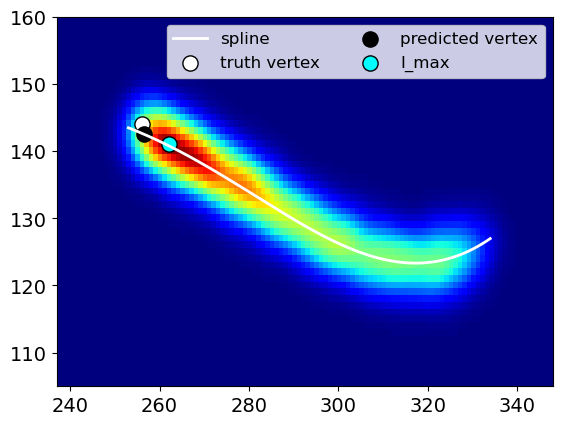

(256.505409,
 142.50632599620968,
 0.13566721406874077,
 -0.2056695904527024,
 1.0258235277699013,
 -0.21521826682164952)

In [300]:
compute_predicted_vertex(combined.query('truth_energy > 500'),18,plot=True)

In [256]:
combined = pd.concat([lowEmatch,highEmatch])
combined.index = [i for i in range(0,len(combined))]

pred_x = []
pred_y = []
dx_truth_pred = []
dy_truth_pred = []
dx_truth_qmax = []
dy_truth_qmax = []
for i in tqdm(range(0,len(combined))):
    px,py,dxp,dyp,dxq,dyq = compute_predicted_vertex(combined,i,plot=False)
    pred_x.append(px)
    pred_y.append(py)
    dx_truth_pred.append(dxp)
    dy_truth_pred.append(dyp)
    dx_truth_qmax.append(dxq)
    dy_truth_qmax.append(dyq)

 21%|████████████▉                                                | 616/2918 [00:17<01:03, 36.12it/s]/tmp/ipykernel_119404/789796934.py:14: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spl = UnivariateSpline(arr[:,0], arr[:,1], k=5)
 21%|████████████▉                                                | 620/2918 [00:17<01:04, 35.70it/s]

Something went wrong


 52%|███████████████████████████████▍                            | 1528/2918 [00:43<00:44, 30.95it/s]/tmp/ipykernel_119404/789796934.py:14: UserWarning: 
A theoretically impossible result was found during the iteration
process for finding a smoothing spline with fp = s: s too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spl = UnivariateSpline(arr[:,0], arr[:,1], k=5)
 73%|███████████████████████████████████████████▊                | 2132/2918 [01:02<00:23, 33.32it/s]

Something went wrong


100%|████████████████████████████████████████████████████████████| 2918/2918 [01:28<00:00, 33.15it/s]


In [257]:
combined['pred_vtx_x'] = pred_x
combined['pred_vtx_y'] = pred_y
combined['dx_pred_to_truth'] = dx_truth_pred
combined['dy_pred_to_truth'] = dy_truth_pred
combined['dx_qmax_to_truth'] = dx_truth_qmax
combined['dy_qmax_to_truth'] = dy_truth_qmax

In [258]:
combined = combined.query('pred_vtx_x >= 0')
combined.index = [i for i in range(0,len(combined))]

Text(0.5, 0, 'Euclidean distance [mm]')

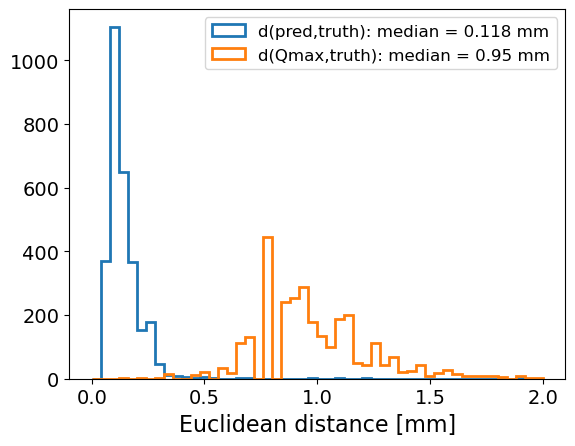

In [200]:
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', labelsize=16)
plt.rc('axes', titlesize=16)
plt.hist(combined['d_pred_to_truth'],bins=50,range=(0,2),histtype='step',lw=2,label='d(pred,truth): median = %s mm'%(np.round(combined['d_pred_to_truth'].median(),3)))
plt.hist(combined['d_qmax_to_truth'],bins=50,range=(0,2),histtype='step',lw=2,label='d(Qmax,truth): median = %s mm'%(np.round(combined['d_qmax_to_truth'].median(),3)))
plt.legend()
plt.xlabel('Euclidean distance [mm]')

(0.0, 1450.0)

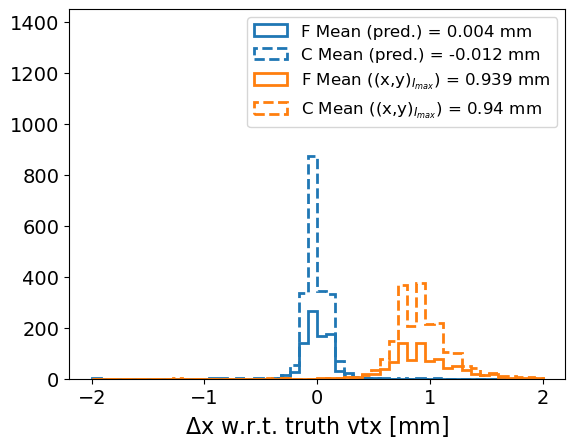

In [306]:
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', labelsize=16)
plt.rc('axes', titlesize=16)
plt.hist(combined.query('species == "F"')['dx_pred_to_truth'],bins=50,range=(-2,2),histtype='step',lw=2,label='F Mean (pred.) = %s mm'%(np.round(combined.query('species == "F"')['dx_pred_to_truth'].mean(),3)))
plt.hist(combined.query('species == "C"')['dx_pred_to_truth'],bins=50,range=(-2,2),color='tab:blue',linestyle='--',histtype='step',lw=2,label='C Mean (pred.) = %s mm'%(np.round(combined.query('species == "C"')['dx_pred_to_truth'].mean(),3)))
plt.hist(combined.query('species == "F"')['dx_qmax_to_truth'],bins=50,range=(-2,2),histtype='step',lw=2,label=r'F Mean ((x,y)$_{I_{max}}$) = %s mm'%(np.round(combined.query('species == "F"')['dx_qmax_to_truth'].mean(),3)))
plt.hist(combined.query('species == "C"')['dx_qmax_to_truth'],bins=50,range=(-2,2),color='tab:orange',linestyle='--',histtype='step',lw=2,label=r'C Mean ((x,y)$_{I_{max}}$) = %s mm'%(np.round(combined.query('species == "C"')['dx_qmax_to_truth'].mean(),3)))
plt.legend()
plt.xlabel(r'$\rm\Delta x$ w.r.t. truth vtx [mm]')
plt.ylim(0,1450)

(0.0, 1250.0)

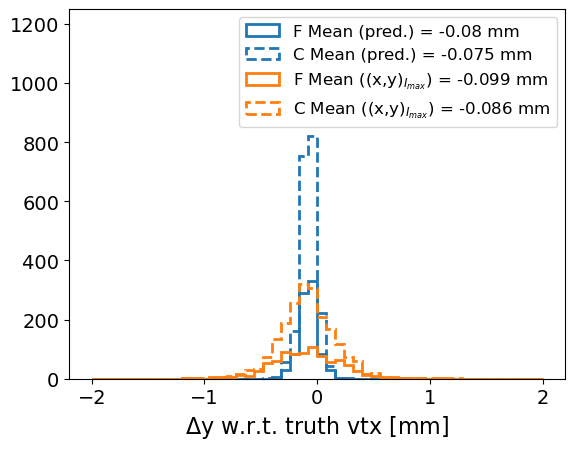

In [311]:
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', labelsize=16)
plt.rc('axes', titlesize=16)
plt.hist(combined.query('species == "F"')['dy_pred_to_truth'],bins=50,range=(-2,2),histtype='step',lw=2,label='F Mean (pred.) = %s mm'%(np.round(combined.query('species == "F"')['dy_pred_to_truth'].mean(),3)))
plt.hist(combined.query('species == "C"')['dy_pred_to_truth'],bins=50,range=(-2,2),color='tab:blue',linestyle='--',histtype='step',lw=2,label='C Mean (pred.) = %s mm'%(np.round(combined.query('species == "C"')['dy_pred_to_truth'].mean(),3)))
plt.hist(combined.query('species == "F"')['dy_qmax_to_truth'],bins=50,range=(-2,2),histtype='step',lw=2,label=r'F Mean ((x,y)$_{I_{max}}$) = %s mm'%(np.round(combined.query('species == "F"')['dy_qmax_to_truth'].mean(),3)))
plt.hist(combined.query('species == "C"')['dy_qmax_to_truth'],bins=50,range=(-2,2),color='tab:orange',linestyle='--',histtype='step',lw=2,label=r'C Mean ((x,y)$_{I_{max}}$) = %s mm'%(np.round(combined.query('species == "C"')['dy_qmax_to_truth'].mean(),3)))
plt.legend()
plt.xlabel(r'$\rm\Delta y$ w.r.t. truth vtx [mm]')
plt.ylim(0,1250)

(0.0, 1450.0)

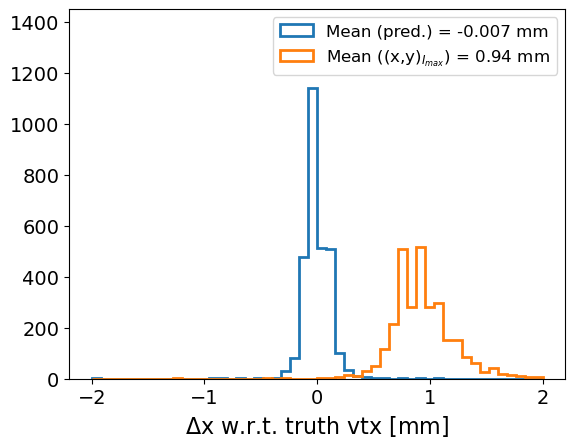

In [312]:
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', labelsize=16)
plt.rc('axes', titlesize=16)
plt.hist(combined['dx_pred_to_truth'],bins=50,range=(-2,2),histtype='step',lw=2,label='Mean (pred.) = %s mm'%(np.round(combined['dx_pred_to_truth'].mean(),3)))
plt.hist(combined['dx_qmax_to_truth'],bins=50,range=(-2,2),histtype='step',lw=2,label=r'Mean ((x,y)$_{I_{max}}$) = %s mm'%(np.round(combined['dx_qmax_to_truth'].mean(),3)))
plt.legend()
plt.xlabel(r'$\rm\Delta x$ w.r.t. truth vtx [mm]')
plt.ylim(0,1450)

(0.0, 1450.0)

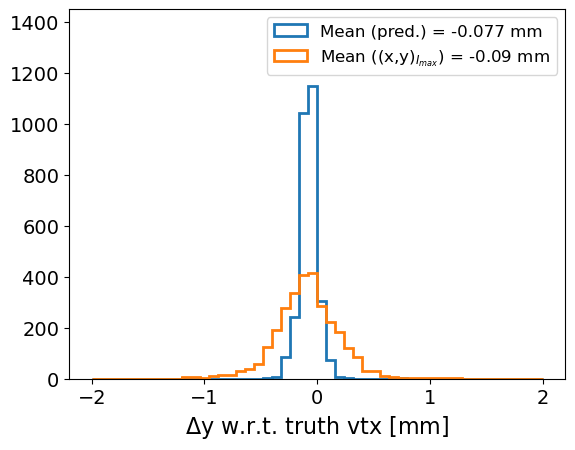

In [313]:
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', labelsize=16)
plt.rc('axes', titlesize=16)
plt.hist(combined['dy_pred_to_truth'],bins=50,range=(-2,2),histtype='step',lw=2,label='Mean (pred.) = %s mm'%(np.round(combined['dy_pred_to_truth'].mean(),3)))
plt.hist(combined['dy_qmax_to_truth'],bins=50,range=(-2,2),histtype='step',lw=2,label=r'Mean ((x,y)$_{I_{max}}$) = %s mm'%(np.round(combined['dy_qmax_to_truth'].mean(),3)))
plt.legend()
plt.xlabel(r'$\rm\Delta y$ w.r.t. truth vtx [mm]')
plt.ylim(0,1450)

In [323]:
cgrp = combined.groupby(pd.cut(combined['truth_energy'],bins=np.linspace(50,700,14)))[['dx_pred_to_truth','dx_qmax_to_truth','dy_pred_to_truth','dy_qmax_to_truth']].agg(list).reset_index()

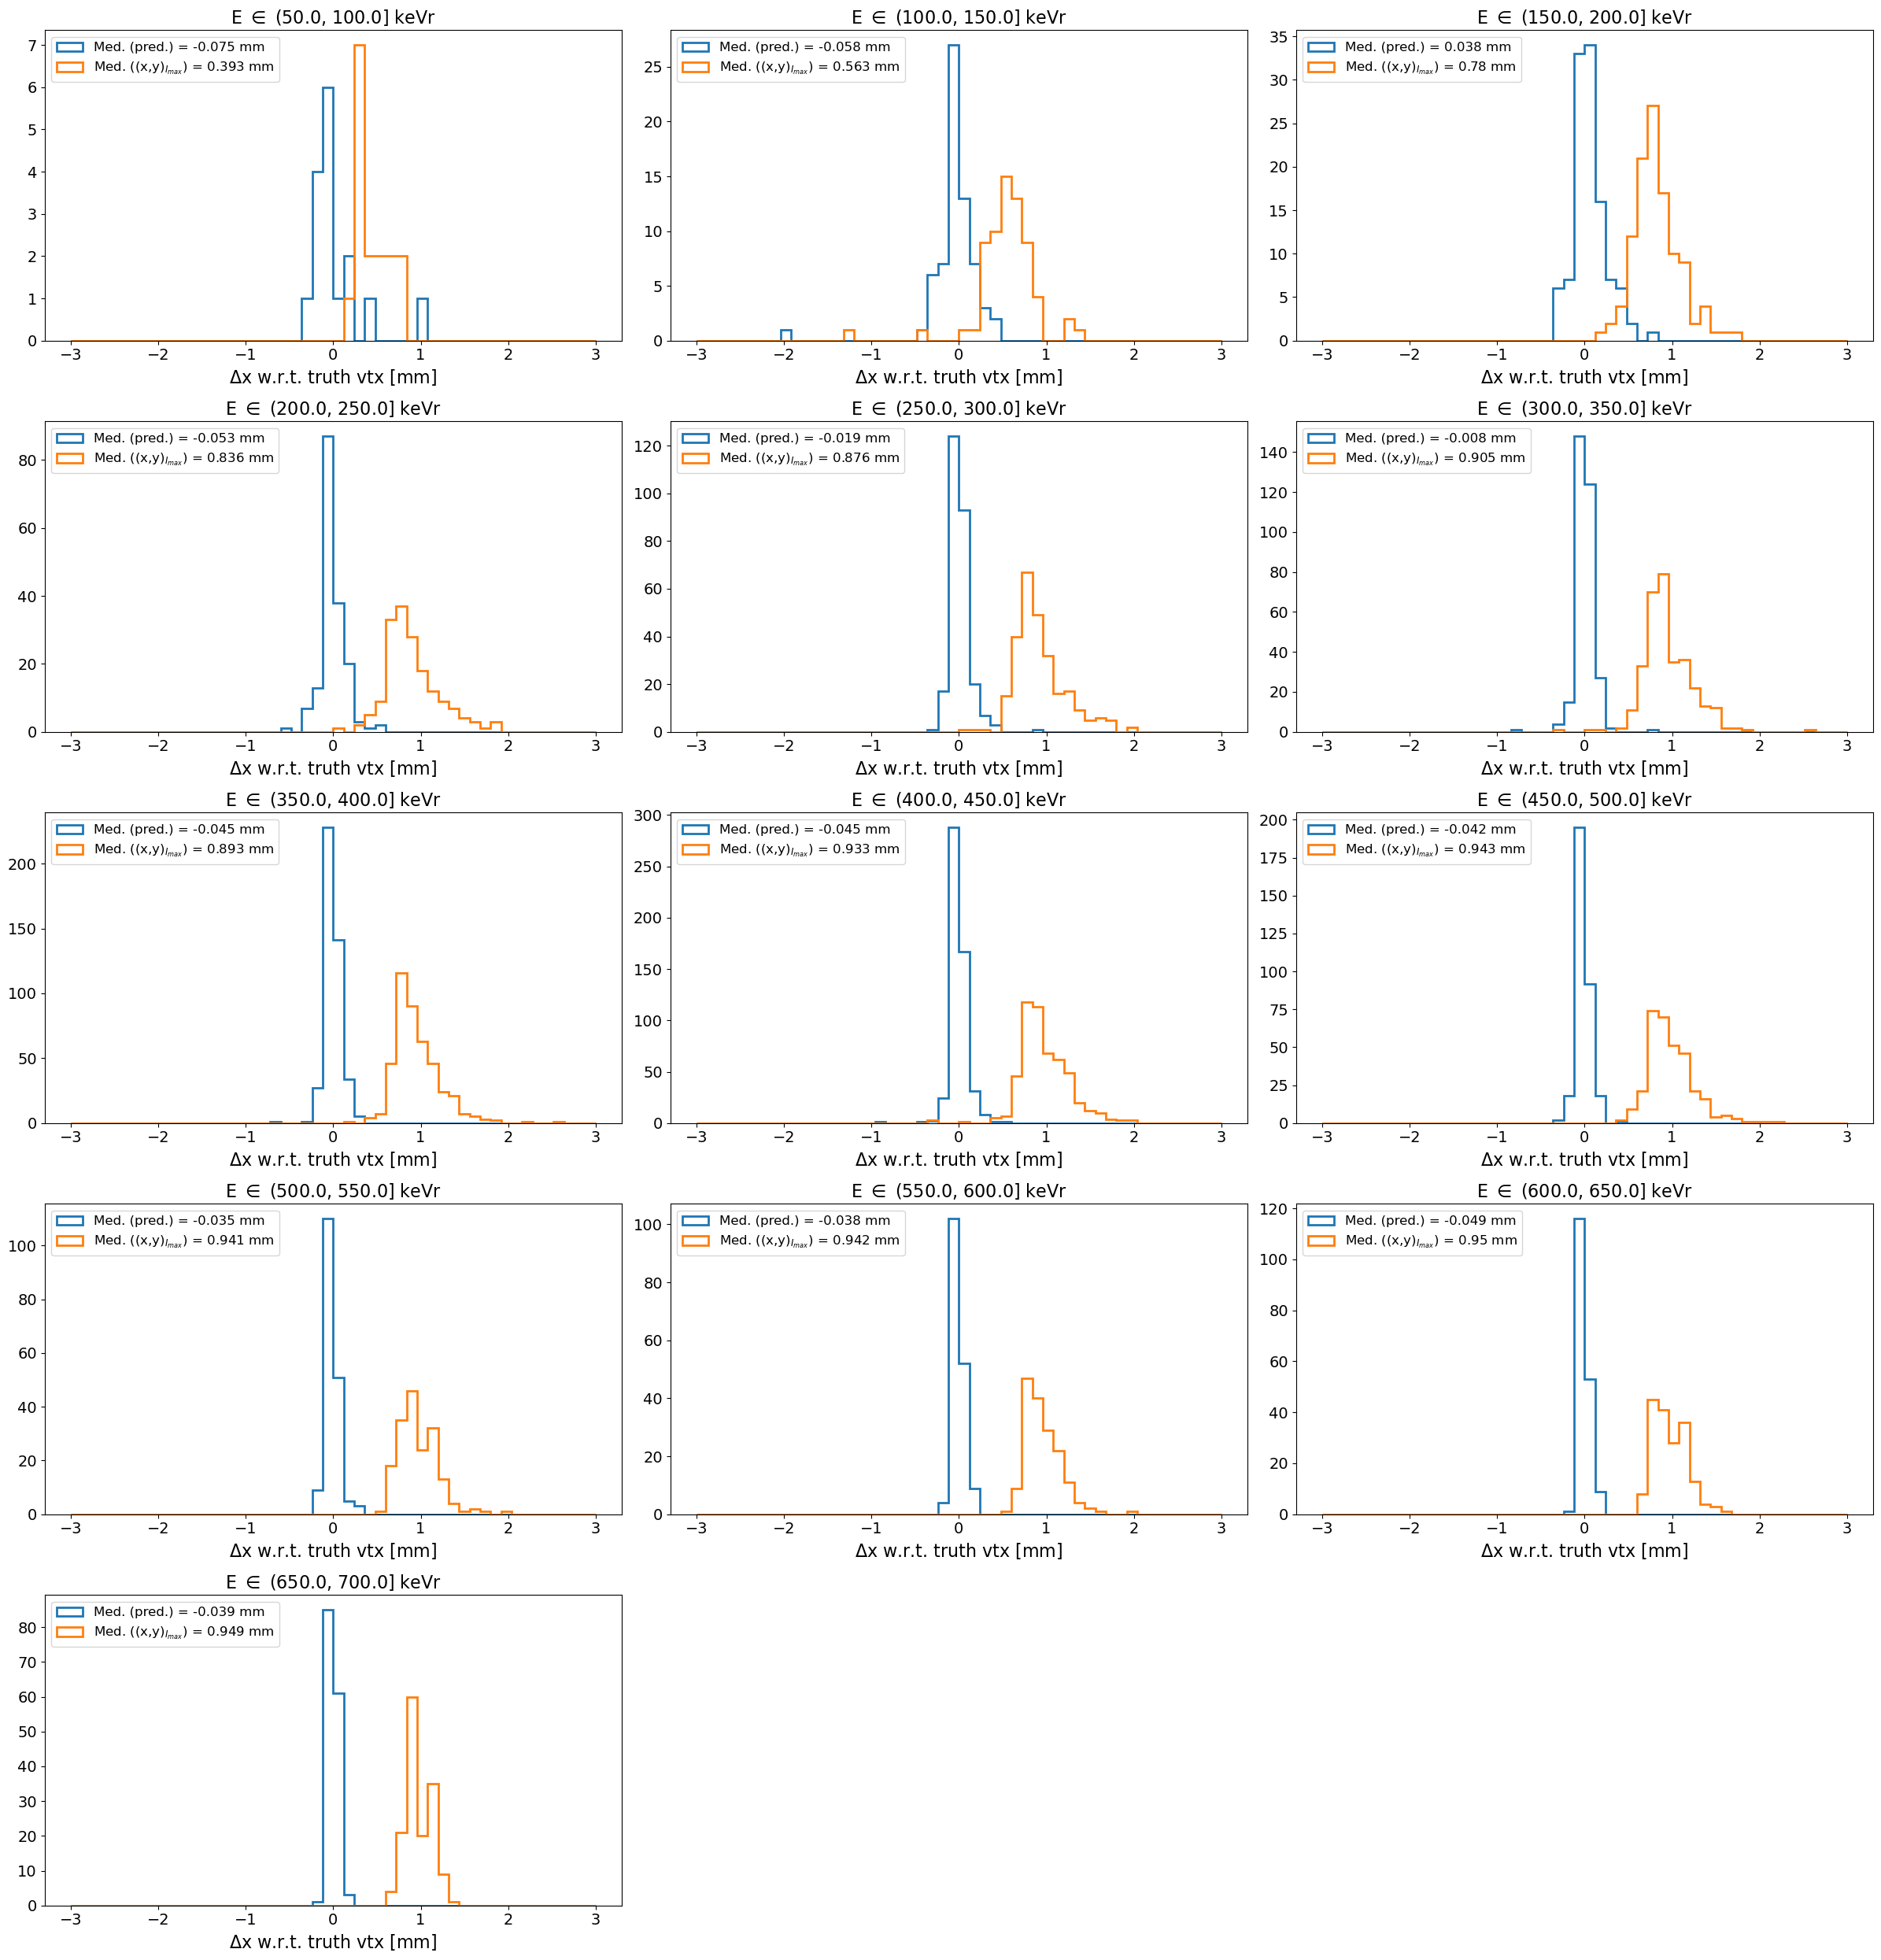

In [329]:
plt.figure(figsize=(24,25))
for i in range(0,len(cgrp)):
    plt.subplot(5,3,i+1)
    tmp = cgrp.iloc[i]
    plt.hist(tmp['dx_pred_to_truth'],bins=50,range=(-3,3),histtype='step',lw=2,label='Med. (pred.) = %s mm'%(np.round(np.median(tmp['dx_pred_to_truth']),3)))
    plt.hist(tmp['dx_qmax_to_truth'],bins=50,range=(-3,3),histtype='step',lw=2,label=r'Med. ((x,y)$_{I_{max}}$) = %s mm'%(np.round(np.median(tmp['dx_qmax_to_truth']),3)))
    plt.title(r'E $\in$ %s keVr'%(tmp['truth_energy']))
    plt.legend(loc = 'upper left')
    plt.xlabel(r'$\rm\Delta x$ w.r.t. truth vtx [mm]')
    plt.tight_layout()

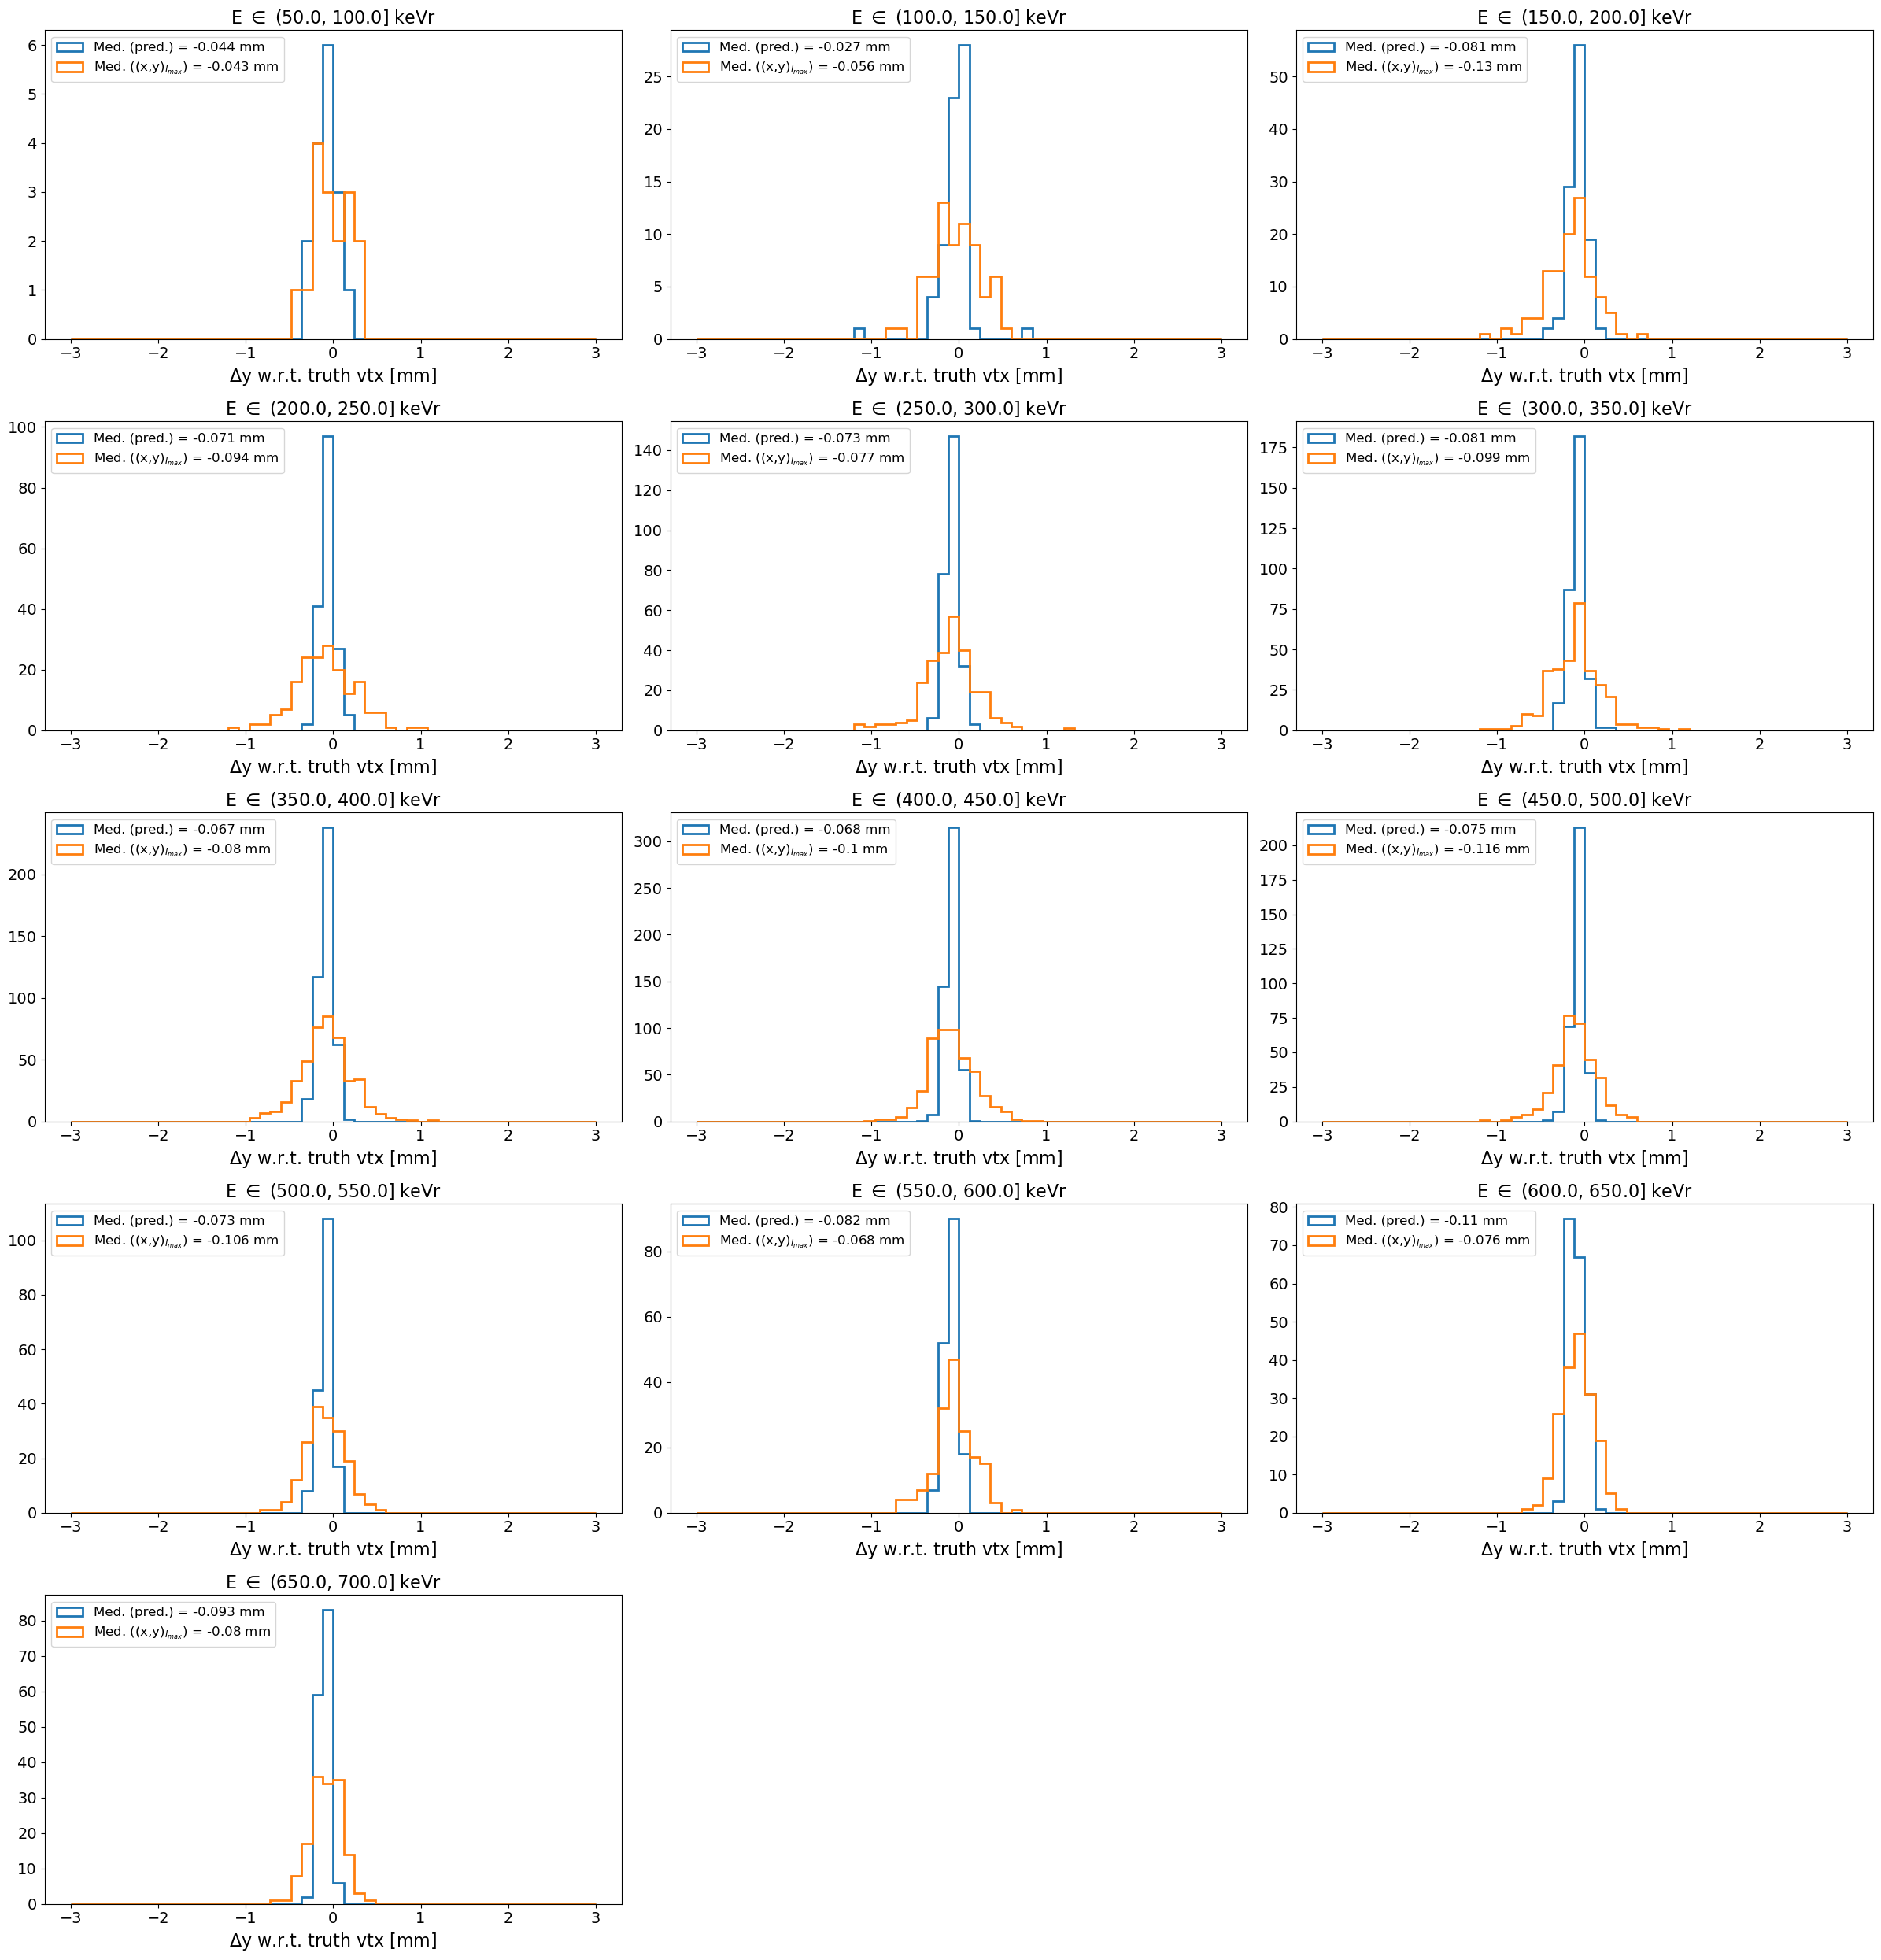

In [330]:
plt.figure(figsize=(24,25))
for i in range(0,len(cgrp)):
    plt.subplot(5,3,i+1)
    tmp = cgrp.iloc[i]
    plt.hist(tmp['dy_pred_to_truth'],bins=50,range=(-3,3),histtype='step',lw=2,label='Med. (pred.) = %s mm'%(np.round(np.median(tmp['dy_pred_to_truth']),3)))
    plt.hist(tmp['dy_qmax_to_truth'],bins=50,range=(-3,3),histtype='step',lw=2,label=r'Med. ((x,y)$_{I_{max}}$) = %s mm'%(np.round(np.median(tmp['dy_qmax_to_truth']),3)))
    plt.title(r'E $\in$ %s keVr'%(tmp['truth_energy']))
    plt.legend(loc = 'upper left')
    plt.xlabel(r'$\rm\Delta y$ w.r.t. truth vtx [mm]')
    plt.tight_layout()

### Try real data

In [483]:
ridgepath='/home/jeff/Fiji/data'
#testridge1 = pd.read_csv(os.path.join(ridgepath,"NR_realData_stack.csv"))
#testridge = pd.read_csv(os.path.join(ridgepath,"NR_realData_stack_best.csv")) #Better, more frames
testridge = pd.read_csv(os.path.join(ridgepath,"NR_realData_stack_lowthresh.csv")) #Better, more frames

In [484]:
df['Frame'] = df.index + 1

In [485]:
datagrp = testridge.groupby('Frame').agg(list).reset_index()

In [486]:
datamatch = df.loc[df['Frame'].isin(datagrp['Frame'])]

In [487]:
datamatch.index = [i for i in range(0,len(datamatch))]
datamatch['x_ridge'] = datagrp['X']
datamatch['y_ridge'] = datagrp['Y']

/tmp/ipykernel_119404/1056634450.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datamatch['x_ridge'] = datagrp['X']
/tmp/ipykernel_119404/1056634450.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datamatch['y_ridge'] = datagrp['Y']


In [571]:
from scipy.interpolate import UnivariateSpline
import numpy as np
import matplotlib.pyplot as plt

def compute_predicted_vertex(df, i, bin_fact=4, plot=True, sim = False):
    tmp = df.iloc[i]

    # --- 1) Build and sort your ridge for the spline ---
    arr = np.vstack((tmp['x_ridge'], tmp['y_ridge'])).T
    sort_idx = arr[:,0].argsort()
    arr = arr[sort_idx]  # now arr[0] is the 'start' of the ridge

    # fit a smooth y(x)
    spl = UnivariateSpline(arr[:,0], arr[:,1], k=5)
    
    if sim:
        # --- 2) Build your (possibly blurred) 2D map ---
        im = np.histogram2d(
            tmp['col'], tmp['row'],
            weights=tmp['intensity'],
            bins=(2048//bin_fact, 1152//bin_fact),
            range=((0,2048),(0,1152))
        )[0].T
        if gb:
            gaussian_blur = GaussianBlur(kernel_size=9, sigma=(4/3,4/3))
            im = gaussian_blur(torch.tensor(im).unsqueeze(0)).squeeze(0).numpy()
    else:
        im = tmp['im']

    # --- 3) Find the intensity threshold and locate predicted vertex ---
    if sim:
        ratio = sample_ratio_given_energy(tmp['truth_energy'], hist, xedges, ye)
    else:
        ratio = sample_ratio_given_energy(tmp['energy'], hist, xedges, ye)
    target = ratio * im.max()

    xtest = np.linspace(arr[0,0], arr[-1,0], 1001)
    ytest = spl(xtest)

    pred_vtx_x = pred_vtx_y = -1
    try:
        for i, (xi, yi) in enumerate(zip(xtest, ytest)):
            if im[int(round(yi)), int(round(xi))] >= target:
                pred_vtx_x, pred_vtx_y = xi, yi
                break
    except:
        print("Something went wrong")
        return -1, -1, -1, -1, -1, -1

    start_pt = arr[0]      # [ x_start, y_start ]

    # check if prediction hit the first spline‐point or second spline point

    if i<2:
        # compute tangent at the start
        slope0 = spl.derivative(n=1)(start_pt[0])
        t      = np.array([1.0, slope0])
        t     /= np.linalg.norm(t)

        # build a set of points from s_min → 0 along the tangent
        n_ext   = 100
        s_ext   = np.linspace(-10, 0.0, n_ext)
        ext_pts = start_pt[None,:] + np.outer(s_ext, t)  # (n_ext,2)

        # clamp to image bounds
        H, W = im.shape
        good = ((ext_pts[:,0] >= 0)&(ext_pts[:,0] < W) &
                (ext_pts[:,1] >= 0)&(ext_pts[:,1] < H))
        ext_pts = ext_pts[good]

        # now prepend these to the spline path
        ridge_pts = np.column_stack((xtest, ytest))
        path_pts  = np.vstack((ext_pts, ridge_pts))
        print()

        # rescan
        for xi,yi in path_pts:
            if im[int(round(yi)), int(round(xi))] >= target:
                pred_vtx_x, pred_vtx_y = xi, yi
                break

    # --- 4) Compute unit tangent & perpendicular at the *start* of the ridge ---
    x0 = arr[0,0]
    slope0 = spl.derivative(n=1)(x0)           # dy/dx at the first ridge point
    t = np.array([1.0, slope0])
    t /= np.linalg.norm(t)                     # unit tangent
    p = np.array([-t[1], t[0]])                # unit normal (perpendicular)

    # --- 5) Gather truth‐vertex and peak‐intensity coordinates in pixel space ---
    if sim:
        truth_pt = np.array([tmp['cam_vtx_x']//bin_fact,
                         tmp['cam_vtx_y']//bin_fact])
    highq   = np.unravel_index(np.argmax(im), im.shape)
    peak_pt  = np.array([highq[1], highq[0]])

    # --- 6) Build the delta‐vectors (predicted minus truth / peak) ---
    pred_pt = np.array([pred_vtx_x, pred_vtx_y])
    if sim:
        delta_truth = pred_pt - truth_pt
        delta_peak  = peak_pt - truth_pt

    # --- 7) Project each delta onto (tangent, perp) and scale to physical units ---
    scale = 80.0 / (2048.0 / bin_fact)
    if sim:
        parallel_truth   = delta_truth.dot(t) * scale
        perpendicular_truth = delta_truth.dot(p) * scale
        parallel_peak    = delta_peak.dot(t) * scale
        perpendicular_peak  = delta_peak.dot(p) * scale

    # --- 8) Optional plotting ---
    if plot:
        plt.imshow(im, cmap='jet', aspect='auto')
        plt.colorbar()
        #plt.plot(tmp['x_ridge'],tmp['y_ridge'],color='magenta',lw=4,label='ridge')
        plt.plot(xtest, ytest, 'w-', lw=4, label='spline')
        #plt.scatter(*truth_pt[::-1], c='white', s=120, edgecolor='k', label='truth vertex')
        if sim:
            plt.scatter(tmp['cam_vtx_x']//bin_fact,tmp['cam_vtx_y']//bin_fact,color='white',s=150,edgecolor='k',label='truth vertex')
        plt.scatter(pred_vtx_x, pred_vtx_y, c='k', s=250, edgecolor='k', label='predicted vertex')
        plt.scatter(highq[1], highq[0], c='cyan', s=150, edgecolor='k', label='I_max')
        #plt.scatter(truth_pt[0], truth_pt[1], facecolors='none', edgecolors='red', s=200, lw=2)
        plt.legend(ncol=2)
        if sim:
            plt.xlim(tmp['col'].min()//bin_fact-5, tmp['col'].max()//bin_fact+5)
            plt.ylim(tmp['row'].min()//bin_fact-5, tmp['row'].max()//bin_fact+5)
        else:
            plt.xlim(tmp['colmin']-2, tmp['colmax'].max()+2)
            plt.ylim(tmp['rowmin']-2, tmp['rowmax'].max()+2)
            plt.title(tmp['energy'])
        #plt.show()

    # --- 9) Return the predicted vertex plus the four displacement components ---
    if sim:
        return (
            pred_vtx_x,
            pred_vtx_y,
            parallel_truth,
            perpendicular_truth,
            parallel_peak,
            perpendicular_peak
        )
    else:
        return (pred_vtx_x,
            pred_vtx_y)


In [489]:
datamatch

,file_key,ER_file,ITO_energy,true_length,theta,HCF,prediction,prob,intensity,gauss_intensity,...,NR_fpath,im,truth_dir,length,width,peak_frac_along_x,width_over_length,Frame,x_ridge,y_ridge
0,MIG_DD_555V_240117T100033.DATA.0001.MTIFF.151,[/opt/ppd/scratch/jschueler1/simInput/CF4_e_dr...,110.502083,8.652249,100.736313,0.421034,2.0,0.871720,385431.12500,385881.46875,...,/opt/ppd/scratch/jschueler1/simOutput/hybrids/...,"[[-17.384289455160896, -16.609054716771087, -1...","[1.0, 0.0, 0.0]",8.12500,5.46875,0.423077,0.673077,1,"[131.997, 130.989, 129.896, 128.959, 128.091, ...","[250.77, 250.777, 250.637, 250.903, 251.27, 25..."
1,MIG_DD_555V_240117T100033.DATA.0167.MTIFF.54,[/opt/ppd/scratch/jschueler1/simInput/CF4_e_dr...,71.660417,8.182230,36.310643,0.468203,2.0,0.862395,296093.00000,297428.37500,...,/opt/ppd/scratch/jschueler1/simOutput/hybrids/...,"[[-3.1233514852246143, -2.079147934438877, 0.9...","[1.0, 0.0, 0.0]",6.87500,5.93750,0.473684,0.863636,2,"[321.91, 322.078, 322.129, 322.009, 321.467, 3...","[99.008, 97.986, 96.962, 95.996, 94.858, 93.97..."
2,MIG_DD_555V_240117T100033.DATA.0203.MTIFF.98,[/opt/ppd/scratch/jschueler1/simInput/CF4_e_dr...,85.908507,9.028278,95.259801,0.400251,2.0,0.851112,446661.87500,447041.75000,...,/opt/ppd/scratch/jschueler1/simOutput/hybrids/...,"[[-5.438276781716191, -4.3108033559178, -2.515...","[1.0, 0.0, 0.0]",8.75000,5.46875,0.357143,0.625000,3,"[319.837, 319.782, 318.986, 318.149, 317.97, 3...","[24.796, 25.61, 25.978, 26.193, 26.929, 27.088..."
3,MIG_DD_555V_240117T100033.DATA.0223.MTIFF.94,[/opt/ppd/scratch/jschueler1/simInput/CF4_e_dr...,61.273958,7.636264,-158.623575,0.443445,2.0,0.849168,295314.78125,296303.84375,...,/opt/ppd/scratch/jschueler1/simOutput/hybrids/...,"[[-3.072164663270447, -1.2069597701954147, 2.3...","[1.0, 0.0, 0.0]",6.71875,6.25000,0.475000,0.930233,4,"[319.644, 320.05, 319.944, 319.838, 319.716, 3...","[135.025, 133.991, 133.013, 132.047, 131.115, ..."
4,MIG_DD_555V_240117T100033.DATA.0230.MTIFF.45,[/opt/ppd/scratch/jschueler1/simInput/CF4_e_dr...,100.965799,7.837145,107.969165,0.483731,2.0,0.897325,499803.15625,500189.93750,...,/opt/ppd/scratch/jschueler1/simOutput/hybrids/...,"[[0.8047449471053066, -0.029019718682214556, -...","[1.0, 0.0, 0.0]",7.18750,5.93750,0.413043,0.826087,5,"[306.018, 304.848, 303.962, 303.152, 302.753, ...","[61.041, 61.597, 61.919, 62.307, 62.486, 62.88..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,MIG_DD_556V_240119T143912.DATA.0057.MTIFF.73,[/opt/ppd/scratch/jschueler1/simInput/CF4_e_dr...,107.173090,7.692409,96.295108,0.418545,2.0,0.865458,261925.15625,261480.40625,...,/opt/ppd/scratch/jschueler1/simOutput/hybrids/...,"[[-6.759666271373055, -5.077162937608145, -1.0...","[1.0, 0.0, 0.0]",7.18750,5.15625,0.456522,0.717391,283,"[60.985, 59.927, 58.996, 58.047, 56.987, 55.97...","[47.817, 47.701, 47.983, 48.299, 48.656, 48.69..."
228,MIG_DD_556V_240119T143912.DATA.0096.MTIFF.144,[/opt/ppd/scratch/jschueler1/simInput/CF4_e_dr...,121.984549,9.116654,85.374410,0.387823,2.0,0.855347,387163.43750,388255.81250,...,/opt/ppd/scratch/jschueler1/simOutput/hybrids/...,"[[-3.860255376682357, -2.1776703021309194, 2.1...","[1.0, 0.0, 0.0]",8.90625,4.68750,0.350877,0.526316,285,"[467.025, 465.942, 464.908, 463.964, 463.006, ...","[119.309, 119.415, 119.546, 119.816, 120.062, ..."
229,MIG_DD_559V_240123T120905.DATA.0026.MTIFF.91,[/opt/ppd/scratch/jschueler1/simInput/CF4_e_dr...,57.166493,12.135450,101.335487,0.407114,2.0,0.869339,754205.62500,756936.25000,...,/opt/ppd/scratch/jschueler1/simOutput/hybrids/...,"[[2.2868362955020416, 0.23269176999064753, -3....","[1.0, 0.0, 0.0]",11.56250,6.40625,0.324324,0.554054,287,"[151.384, 150.437, 150.068, 149.379, 148.977, ...","[180.502, 180.355, 181.074, 181.271, 181.979, ..."
230,MIG_DD_559V_240123T120905.DATA.0153.MTIFF.107,[/opt/ppd/scratch/jschueler1/simInput/CF4_e_dr...,161.420313,10.124356,-98.587954,0.494701,2.0,0.873276,676140.81250,676326.87500,...,/opt/ppd/

In [515]:
len(datamatch)/len(df)

0.8

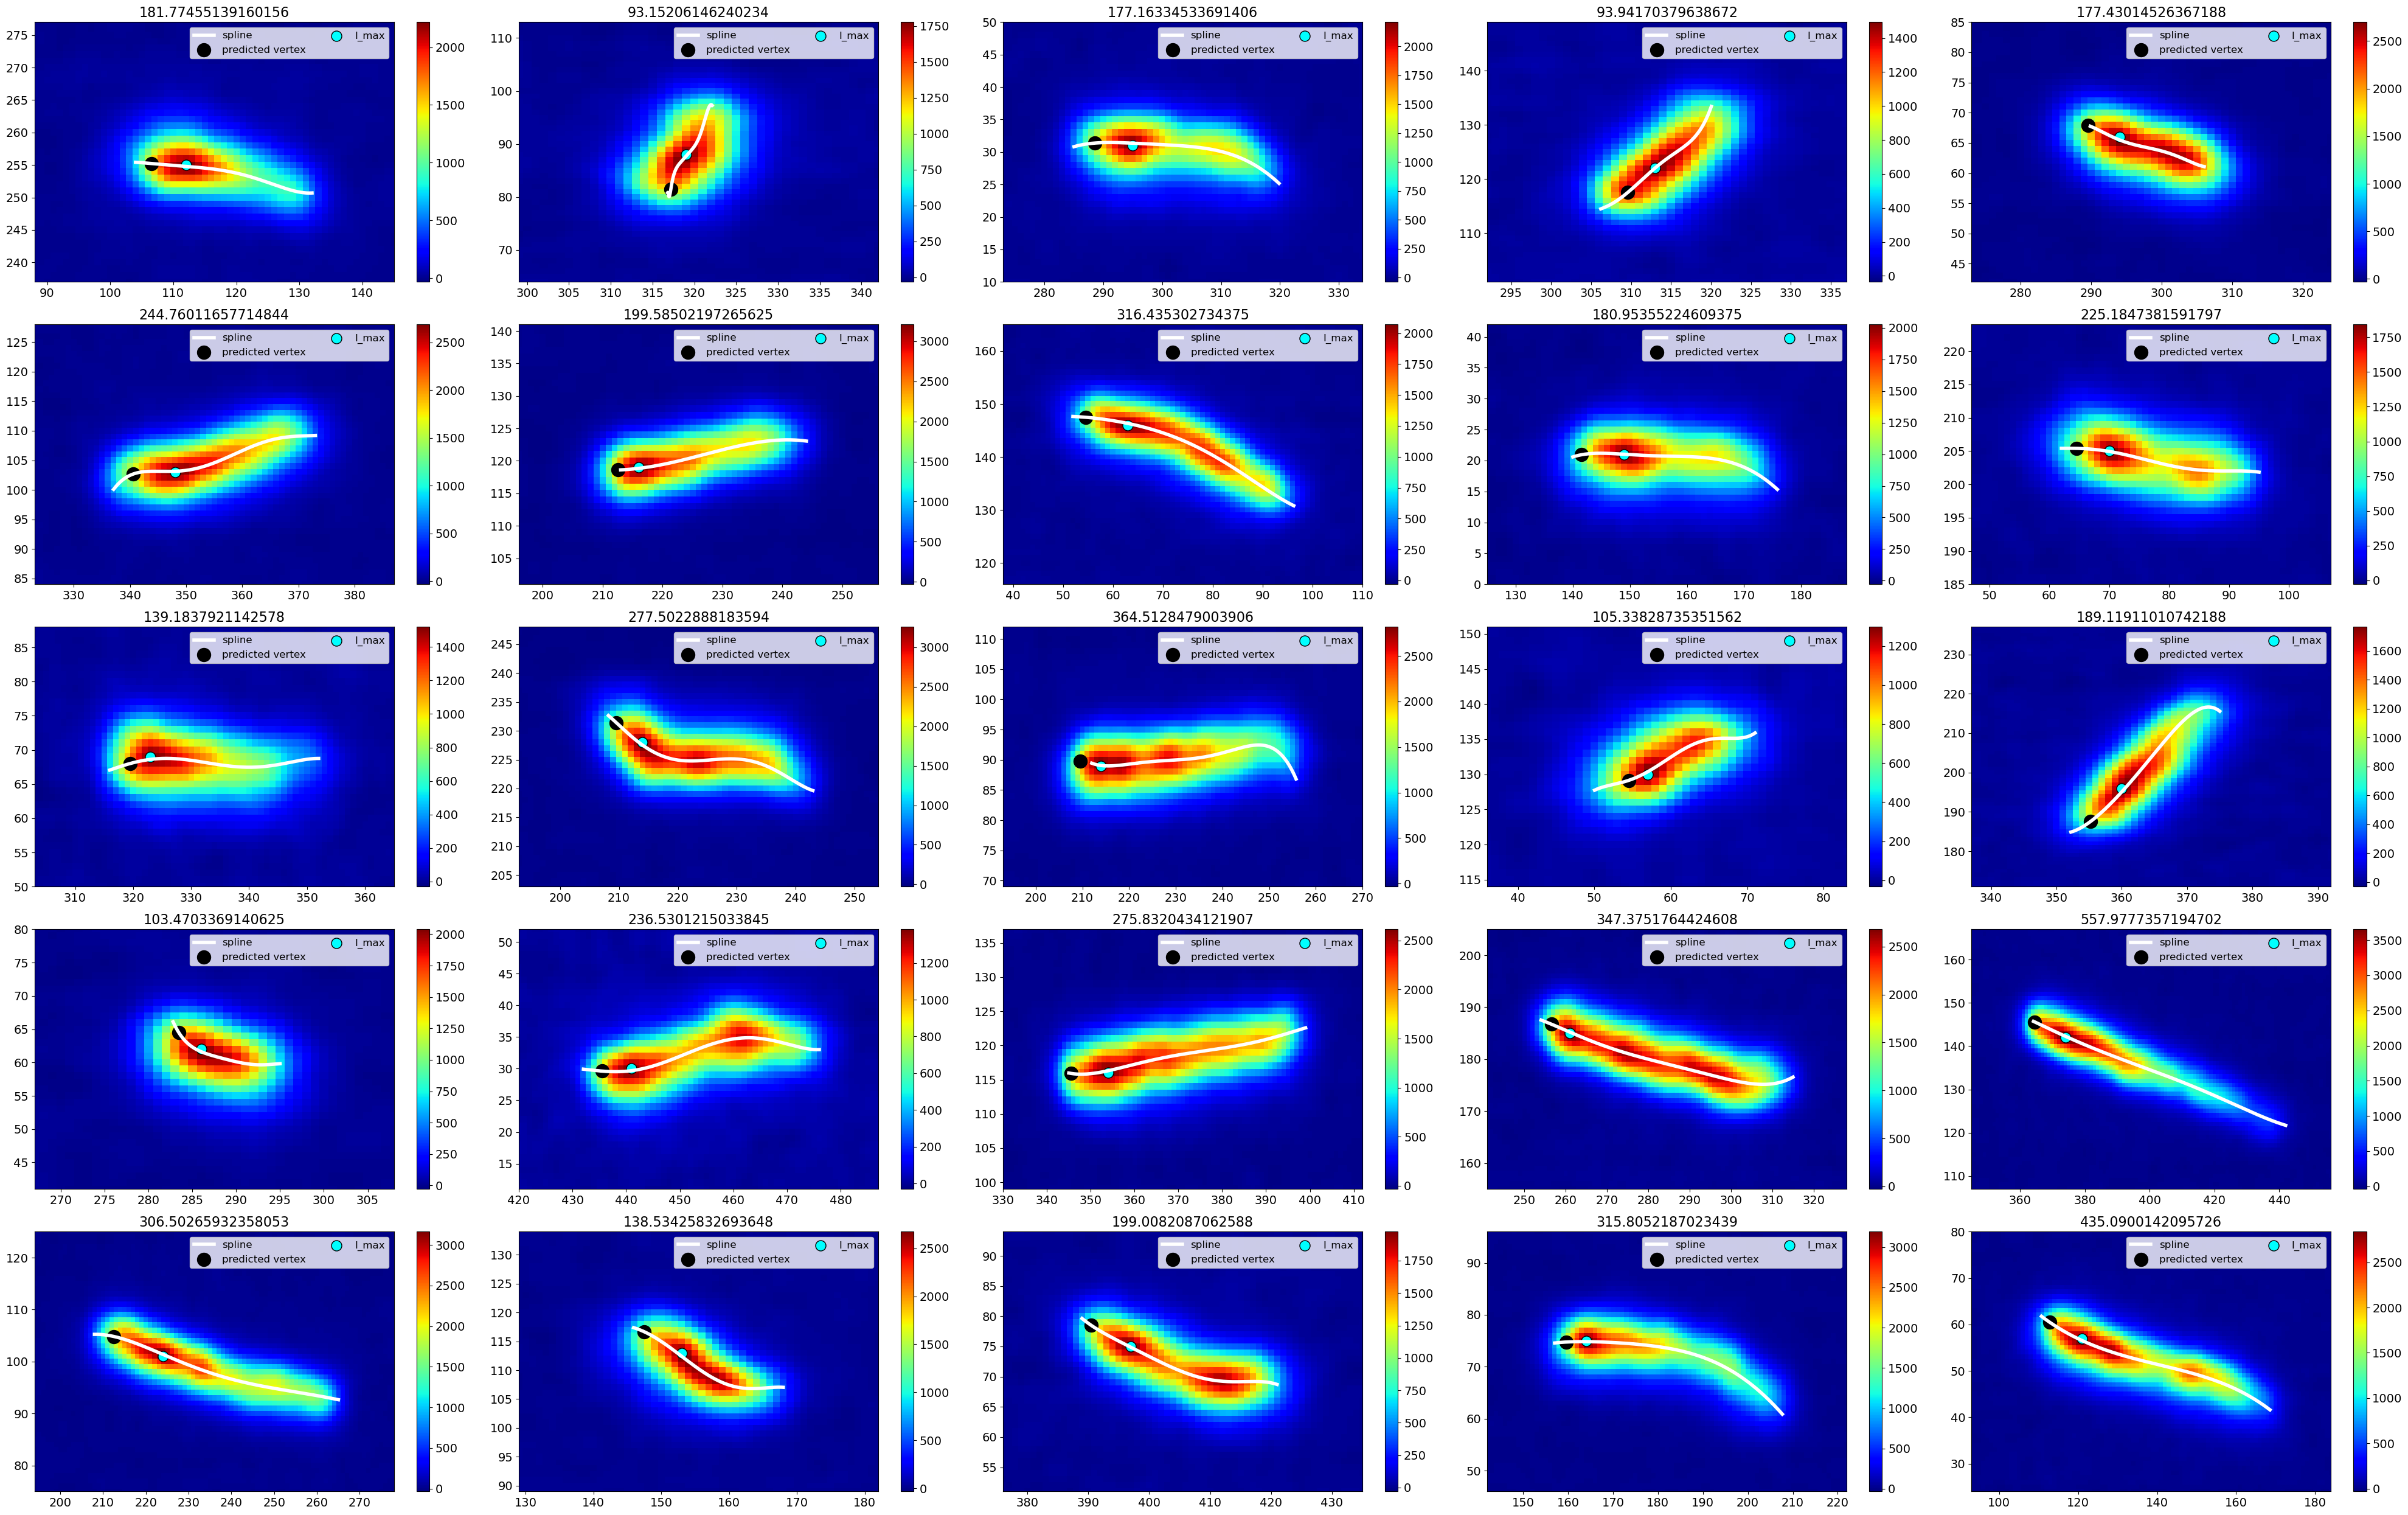

In [572]:
plt.figure(figsize=(40,25))
for i in range(0,25):
    plt.subplot(5,5,i+1)
    compute_predicted_vertex(datamatch, i, bin_fact=4, plot=True, sim = False)
plt.tight_layout()
plt.show()

(209.58507413998205, 89.73098473126367)

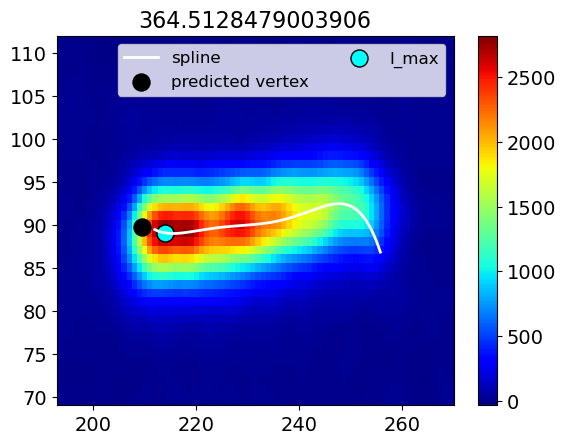

In [570]:
compute_predicted_vertex(datamatch, 12, bin_fact=4, plot=True, sim = False)